In [1]:

import numpy as np
import polars as pl
from aeon.datasets.tsc_datasets import univariate

from autotsc import utils

In [2]:
# from amltk.ensembling.weighted_ensemble_caruana import weighted_ensemble_caruana
#
# X1 = np.random.rand(m.test_pred1.shape[0], m.test_pred1.shape[1])
# X1 = X1 / X1.sum(axis=1, keepdims=True)
#
# X2 = np.random.rand(m.test_pred1.shape[0], m.test_pred1.shape[1])
# X2 = X2 / X2.sum(axis=1, keepdims=True)
#
# X3 = np.random.rand(m.test_pred1.shape[0], m.test_pred1.shape[1])
# X3 = X3 / X3.sum(axis=1, keepdims=True)
#
# model_predictions = {
#    'MR': m.test_pred1,
#    'QUANT': m.test_pred2,
#    'RDST': m.test_pred3,
#    'TEST': X1,
#    'TEST2': X2,
#    'TEST3': X3,
# }
#
# for k, v in model_predictions.items():
#    print(k, v.shape)
#
# def accuracy(y_true, y_pred):
#    # Convert to integers (0,1,2,3) for argmax comparison
#    # but *does not* affect predictions
#    unique = sorted(set(y_true))
#    mapping = {label: i for i, label in enumerate(unique)}
#    y_idx = np.array([mapping[x] for x in y_true])
#
#    y_hat = np.argmax(y_pred, axis=1)
#    return np.mean(y_hat == y_idx)
#
# weights, traj, final_pred = weighted_ensemble_caruana(
#    model_predictions=model_predictions,
#    targets=y_test,
#    size=350,                                  # ensemble size / num of draws
#    metric=accuracy,
#    select=max,
# )
#
# weights

In [3]:
df = (
    pl.read_parquet("s3://tsc-glue/experiments/stacking_run_v1/*.parquet")
    .filter(pl.col("model") != "mixed-v2")
    .filter(pl.col("model") != "mixed")
)
df

/tmp/ipykernel_2380261/1401064196.py:1: UserWarning: '(default_)region' not set; polars will try to get it from bucket

Set the region manually to silence this warning.
  df = pl.read_parquet("s3://tsc-glue/experiments/stacking_run_v1/*.parquet").filter(pl.col('model') != 'mixed-v2').filter(pl.col('model') != 'mixed')


dataset,model,run,test_accuracy
str,str,i64,f64
"""ECG5000""","""mr-hydra""",200,0.946222
"""GestureMidAirD2""","""mr-hydra""",300,0.7
"""PLAID""","""quant""",300,0.947858
"""ECGFiveDays""","""rdst""",400,0.997677
"""Wafer""","""quant""",500,1.0
…,…,…,…
"""UWaveGestureLibraryAll""","""quant""",300,0.967895
"""SmallKitchenAppliances""","""quant""",200,0.848
"""PigAirwayPressure""","""quant""",300,0.442308


In [4]:
from aeon.visualisation import plot_critical_difference

In [5]:
v = df.pivot(
    on="model", values="test_accuracy", index="dataset", aggregate_function="mean"
).drop_nulls()
methods = df["model"].unique().to_list()
v

dataset,mr-hydra,quant,rdst,mixed-v3,mixed-v4-ray,mixed-v4
str,f64,f64,f64,f64,f64,f64
"""ECG5000""",0.946222,0.943278,0.944756,0.947,0.947333,0.947022
"""PLAID""",0.941899,0.945624,0.935444,0.955773,0.955307,0.955307
"""Wafer""",0.999676,1.0,1.0,0.999838,0.999838,0.999903
"""CricketY""",0.849231,0.805128,0.835897,0.84359,0.852564,0.851795
"""Beef""",0.766667,0.791667,0.833333,0.773333,0.783333,0.806667
…,…,…,…,…,…,…
"""Herring""",0.730469,0.590625,0.6796875,0.566406,0.5625,0.5859375
"""ItalyPowerDemand""",0.969226,0.9655,0.944606,0.964431,0.968902,0.966958
"""OliveOil""",0.966667,0.933333,0.888889,0.911111,0.9,0.9


(<Figure size 600x250 with 1 Axes>, <Axes: >)

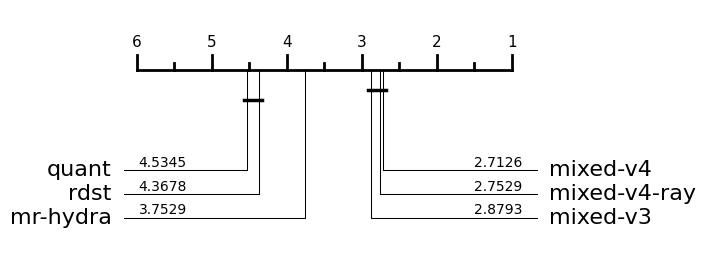

In [6]:
plot_critical_difference(v.select(methods).to_numpy(), methods)

In [7]:
def dataset_stats():

    stats = []
    for dataset in univariate:
        X_train, y_train, X_test, y_test = utils.load_dataset(dataset)
        stats.append(
            {
                "dataset": dataset,
                "n_train": X_train.shape[0],
                "n_test": X_test.shape[0],
                "n_classes": len(np.unique(y_train)),
                "series_length": X_train.shape[2],
            }
        )
    return pl.DataFrame(stats)


stats = dataset_stats()

In [8]:
joined = v.join(stats, on="dataset").sort("n_train")
joined

dataset,mr-hydra,quant,rdst,mixed-v3,mixed-v4-ray,mixed-v4,n_train,n_test,n_classes,series_length
str,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64
"""DodgerLoopGame""",0.858268,0.867717,0.848819,0.862992,0.866142,0.862992,17,127,2,288
"""InsectEPGSmallTrain""",1.0,1.0,0.991968,1.0,1.0,1.0,17,249,3,601
"""DodgerLoopWeekend""",0.984127,0.984127,0.984127,0.984127,0.984127,0.984127,18,126,2,288
"""BeetleFly""",0.9,0.81,0.95,0.95,0.95,0.95,20,20,2,512
"""BirdChicken""",0.9,0.9,0.9,0.9,0.9,0.9,20,20,2,512
…,…,…,…,…,…,…,…,…,…,…
"""NonInvasiveFetalECGThorax1""",0.961323,0.937659,0.929135,0.960204,0.959288,0.960204,1800,1965,42,750
"""NonInvasiveFetalECGThorax2""",0.967735,0.948397,0.940153,0.967837,0.970483,0.969466,1800,1965,42,750
"""PhalangesOutlinesCorrect""",0.845862,0.840618,0.806915,0.853147,0.855478,0.8581,1800,858,2,80


40


(<Figure size 600x250 with 1 Axes>, <Axes: >)

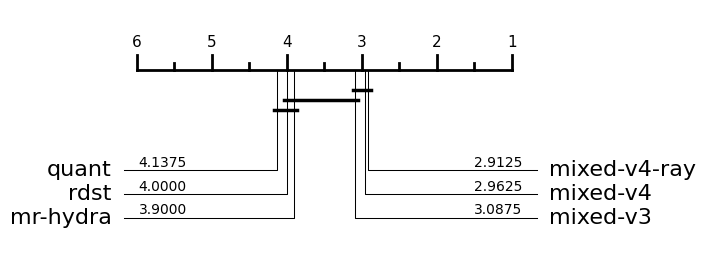

In [9]:
s_small = joined.filter(pl.col("n_train") < 200)
print(len(s_small))
plot_critical_difference(s_small.select(methods).to_numpy(), methods)

33


(<Figure size 600x250 with 1 Axes>, <Axes: >)

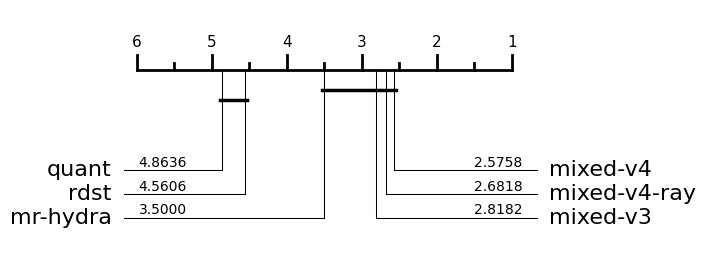

In [10]:
s_medium = joined.filter(pl.col("n_train") >= 200).filter(pl.col("n_train") < 600)
print(len(s_medium))
plot_critical_difference(s_medium.select(methods).to_numpy(), methods)

14


(<Figure size 600x250 with 1 Axes>, <Axes: >)

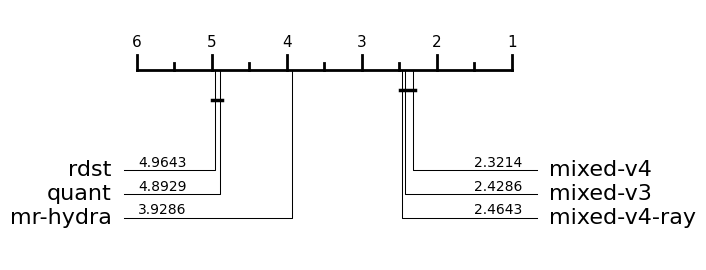

In [11]:
s_large = joined.filter(pl.col("n_train") >= 600)
print(len(s_large))
plot_critical_difference(s_large.select(methods).to_numpy(), methods)

In [12]:
s_large

dataset,mr-hydra,quant,rdst,mixed-v3,mixed-v4-ray,mixed-v4,n_train,n_test,n_classes,series_length
str,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64
"""DistalPhalanxOutlineCorrect""",0.802899,0.788406,0.773188,0.81087,0.810386,0.800725,600,276,2,80
"""MiddlePhalanxOutlineCorrect""",0.851546,0.847938,0.839175,0.867698,0.863688,0.86323,600,291,2,80
"""ShapesAll""",0.9275,0.871667,0.920667,0.924333,0.93,0.92625,600,600,60,512
"""Strawberry""",0.974595,0.969189,0.976216,0.977297,0.977027,0.975676,613,370,2,235
"""UWaveGestureLibraryAll""",0.979732,0.967281,0.979788,0.979527,0.979062,0.980109,896,3582,8,945
…,…,…,…,…,…,…,…,…,…,…
"""NonInvasiveFetalECGThorax1""",0.961323,0.937659,0.929135,0.960204,0.959288,0.960204,1800,1965,42,750
"""NonInvasiveFetalECGThorax2""",0.967735,0.948397,0.940153,0.967837,0.970483,0.969466,1800,1965,42,750
"""PhalangesOutlinesCorrect""",0.845862,0.840618,0.806915,0.853147,0.855478,0.8581,1800,858,2,80
